In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PENGUMPULAN DATA

In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/semhas kode/data radiosonde 19-25_gabung.xlsx'

df = pd.read_excel(file_path)
df

,Tanggal,850 00.00,850 12.00,700 00.00,700 12.00,500 00.00,500 12.00,SWEAT 00.00,SWEAT 12.00,LCL 00.00,...,CIN 12.00,MVV 00.00,MVV 12.00,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72,38,55.0,"227,2","227,5",403,...,-24,41,55,0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92,86,94.0,"206,1","237,3",503,...,-42,41,35,0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89,100,98.0,"221,7","223,8",194,...,-21,39,44,"6,8",12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70,94,72.0,"198,4","223,4",168,...,0,33,70,"38,5",10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65,81,80.0,"220,2","193,1",168,...,-22,42,64,1,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,NaN,NaN,NaN,NaN,NaN,NaN,205.2,0,404,...,NaN,NaN,NaN,10,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,188.5,232.9,155,...,NaN,NaN,NaN,10,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,183.6,242.5,430,...,NaN,NaN,NaN,0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,219.9,220.8,185,...,NaN,NaN,NaN,0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PREPROCESSING

In [5]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '', regex=False)

In [6]:
# konversi data
df = df.replace(',', '.', regex=True)
exclude_cols = ['Tanggal']
for col in df.columns:
    if col not in exclude_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['Tanggal'] = pd.to_datetime(df['Tanggal'])

In [7]:
df

,Tanggal,850_0000,850_1200,700_0000,700_1200,500_0000,500_1200,SWEAT_0000,SWEAT_1200,LCL_0000,...,CIN_1200,MVV_0000,MVV_1200,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72.0,38.0,55.0,227.2,227.5,403.0,...,-24.0,41.0,55.0,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92.0,86.0,94.0,206.1,237.3,503.0,...,-42.0,41.0,35.0,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89.0,100.0,98.0,221.7,223.8,194.0,...,-21.0,39.0,44.0,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70.0,94.0,72.0,198.4,223.4,168.0,...,0.0,33.0,70.0,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65.0,81.0,80.0,220.2,193.1,168.0,...,-22.0,42.0,64.0,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,NaN,NaN,NaN,NaN,NaN,NaN,205.2,0.0,404.0,...,NaN,NaN,NaN,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,188.5,232.9,155.0,...,NaN,NaN,NaN,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,183.6,242.5,430.0,...,NaN,NaN,NaN,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,219.9,220.8,185.0,...,NaN,NaN,NaN,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [8]:
# Cek missing value
df.isnull().sum()

,0
Tanggal,0
850_0000,375
850_1200,912
700_0000,375
700_1200,912
500_0000,376
500_1200,912
SWEAT_0000,49
SWEAT_1200,707
LCL_0000,47


In [9]:
# missing value
df = df.interpolate(method='linear')
df

,Tanggal,850_0000,850_1200,700_0000,700_1200,500_0000,500_1200,SWEAT_0000,SWEAT_1200,LCL_0000,...,CIN_1200,MVV_0000,MVV_1200,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72.0,38.0,55.0,227.2,227.5,403.0,...,-24.0,41.0,55.0,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92.0,86.0,94.0,206.1,237.3,503.0,...,-42.0,41.0,35.0,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89.0,100.0,98.0,221.7,223.8,194.0,...,-21.0,39.0,44.0,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70.0,94.0,72.0,198.4,223.4,168.0,...,0.0,33.0,70.0,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65.0,81.0,80.0,220.2,193.1,168.0,...,-22.0,42.0,64.0,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,85.0,87.0,72.0,80.0,81.0,89.0,205.2,0.0,404.0,...,-16.0,14.0,57.5,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,85.0,87.0,72.0,80.0,81.0,89.0,188.5,232.9,155.0,...,-16.0,14.0,57.5,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,85.0,87.0,72.0,80.0,81.0,89.0,183.6,242.5,430.0,...,-16.0,14.0,57.5,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,85.0,87.0,72.0,80.0,81.0,89.0,219.9,220.8,185.0,...,-16.0,14.0,57.5,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [10]:
df.isnull().sum()

,0
Tanggal,0
850_0000,0
850_1200,0
700_0000,0
700_1200,0
500_0000,0
500_1200,0
SWEAT_0000,0
SWEAT_1200,0
LCL_0000,0


In [11]:
# rata-rata
df['850_avg'] = (df['850_0000'] + df['850_1200']) / 2
df['700_avg'] = (df['700_0000'] + df['700_1200']) / 2
df['500_avg'] = (df['500_0000'] + df['500_1200']) / 2

df['SWEAT_avg'] = (df['SWEAT_0000'] + df['SWEAT_1200']) / 2

df['LCL_avg'] = (df['LCL_0000'] + df['LCL_1200']) / 2
df['CCL_avg'] = (df['CCL_0000'] + df['CCL_1200']) / 2
df['LFC_avg'] = (df['LFC_0000'] + df['LFC_1200']) / 2

df['LI_avg'] = (df['LI_0000'] + df['LI_1200']) / 2
df['KI_avg'] = (df['KI_0000'] + df['KI_1200']) / 2

df['CAPE_avg'] = (df['CAPE_0000'] + df['CAPE_1200']) / 2

df['SI_avg'] = (df['SI_0000'] + df['SI_1200']) / 2

df['TT_avg'] = (df['TT_0000'] + df['TT_1200']) / 2

df['KO_avg'] = (df['KO_0000'] + df['KO_1200']) / 2

df['TPW_avg'] = (df['TPW_0000'] + df['TPW_1200']) / 2

df['BOYDEN_avg'] = (df['BOYDEN_0000'] + df['BOYDEN_1200']) / 2

df['CIN_avg'] = (df['CIN_0000'] + df['CIN_1200']) / 2

df['MVV_avg'] = (df['MVV_0000'] + df['MVV_1200']) / 2

In [12]:
df = df[
    ['Tanggal', 'CH', 'Height', 'Press0', 'Temp0', 'Humi0', 'WS', 'WD']
    + [col for col in df.columns if col.endswith('_avg')]
]

# Hapus suffix "_avg"
df.rename(columns=lambda x: x.replace('_avg', ''), inplace=True)

df

/tmp/ipykernel_513/3907718637.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns=lambda x: x.replace('_avg', ''), inplace=True)


,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


In [13]:
import pandas as pd

file_path = '/content/drive/MyDrive/semhas kode/dataset_bersih.xlsx'

df = pd.read_excel(file_path)
df

,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


In [14]:
df1 = df[df["CH"] <= 80]
df2 = df[df["CH"] > 80]

In [15]:
df1

,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


EDA

In [16]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2533 entries, 0 to 2556
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tanggal  2533 non-null   datetime64[ns]
 1   CH       2533 non-null   float64       
 2   Height   2533 non-null   float64       
 3   Press0   2533 non-null   float64       
 4   Temp0    2533 non-null   float64       
 5   Humi0    2533 non-null   float64       
 6   WS       2533 non-null   float64       
 7   WD       2533 non-null   float64       
 8   850      2533 non-null   float64       
 9   700      2533 non-null   float64       
 10  500      2533 non-null   float64       
 11  SWEAT    2533 non-null   float64       
 12  LCL      2533 non-null   float64       
 13  CCL      2533 non-null   float64       
 14  LFC      2533 non-null   float64       
 15  LI       2533 non-null   float64       
 16  KI       2533 non-null   float64       
 17  CAPE     2533 non-null   float64      

In [17]:
# statistik deskriptif
df1.describe()

,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
count,2533,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,...,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000,2533.000000
mean,2022-06-30 05:58:09.143308288,6.115989,12963.780560,305.135838,-36.720405,37.005897,9.790343,144.332120,78.333128,64.289648,...,-2.513839,28.944637,1207.442595,0.880353,41.417912,-11.194463,5384.985214,95.977068,-78.392880,35.729284
min,2019-01-01 00:00:00,0.000000,321.886897,138.115257,-48.191014,10.343579,2.920282,68.241649,19.000000,1.000000,...,-24.500000,-29.400000,-15.000000,-15.500000,0.400000,-46.083562,1631.500000,47.100000,-581.669492,-191.000000
25%,2020-09-30 00:00:00,0.000000,12190.707531,271.152202,-39.824010,25.661161,8.023553,120.008906,73.109272,53.000000,...,-3.801325,24.969880,645.758389,-0.150000,40.400000,-14.050000,4758.678808,95.650000,-107.500000,20.750000
50%,2022-06-30 00:00:00,0.000000,13539.139116,284.962315,-38.970442,34.303401,9.658664,140.266350,81.500000,72.474576,...,-2.955932,32.393373,1124.000000,0.189471,42.400000,-11.017550,5666.000000,96.250000,-67.000000,34.750000
75%,2024-03-28 00:00:00,3.900000,14162.641832,314.746223,-37.210478,46.161195,11.409971,163.629434,86.000000,78.000000,...,-1.500000,35.450000,1692.500000,1.450000,43.700000,-8.300000,6235.000000,96.750000,-33.656627,47.000000
max,2025-12-30 00:00:00,79.500000,15642.447141,972.642069,26.382759,99.591781,18.451425,330.280000,100.000000,98.500000,...,12.450000,190.500000,19716.000000,17.850000,48.900000,61.550000,29803.072289,101.200000,90.374172,1678.750000
std,NaN,13.459470,1775.897036,61.829819,6.813112,14.125277,2.431025,32.056174,11.461355,20.884539,...,2.038246,11.107599,885.796492,2.012988,3.990440,5.174883,1126.298813,2.600990,60.966254,46.274959


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Jumlah subplot
n = len(df1)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

# Buat figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3 * n_rows),
    sharex=True
)

# Ubah axes menjadi 1 dimensi
axes = np.array(axes).flatten()

# Plot masing-masing variabel
for i, kolom in enumerate(variabel):
    axes[i].plot(
        df["Tanggal"],
        df[kolom],
        linewidth=0.7
    )

    axes[i].set_title(kolom, fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis="x", rotation=30)

# Hapus subplot kosong
for i in range(len(variabel), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(
    "Visualisasi Variabel Meteorologi",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

NameError: name 'variabel' is not defined

Error in callback <function flush_figures at 0x7ad164c9fe20> (for post_execute):


KeyboardInterrupt: 

In [ ]:
df_daily = (
    df1.set_index('Tanggal')['CH']
    .resample('D')
    .first()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_daily.index,
    df_daily.values
)
plt.title('Distribusi Curah Hujan')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan (mm)')
plt.grid(True)

plt.show()

In [19]:
pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 651.3 kB/s eta 0:00:00


In [64]:
pip install optuna

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from pytorch_tabnet.tab_model import TabNetRegressor

from statsmodels.tsa.stattools import ccf

from xgboost import XGBRegressor

import optuna

In [66]:
# Pastikan tanggal bertipe datetime
df1["Tanggal"] = pd.to_datetime(df1["Tanggal"])

# Urutkan berdasarkan waktu
df1 = df1.sort_values(
    "Tanggal"
).reset_index(drop=True)

MENENTUKAN TARGET DAN FITUR AWAL

In [67]:
target = "CH"

features_awal = [
    col for col in df1.columns
    if col not in ["Tanggal", target]
]

print("\nJumlah fitur awal :", len(features_awal))
print(features_awal)



Jumlah fitur awal : 23
['Height', 'Press0', 'Temp0', 'Humi0', 'WS', 'WD', '850', '700', '500', 'SWEAT', 'LCL', 'CCL', 'LFC', 'LI', 'KI', 'CAPE', 'SI', 'TT', 'KO', 'TPW', 'BOYDEN', 'CIN', 'MVV']


CHRONOLOGICAL TRAIN-TEST SPLIT

In [68]:
train_mask = df1["Tanggal"].dt.year <= 2024
test_mask = df1["Tanggal"].dt.year == 2025

df_train = df1.loc[
    train_mask
].copy()

df_test = df1.loc[
    test_mask
].copy()

In [69]:
print("\nTRAINING")
print("Periode :",
      df_train["Tanggal"].min(),
      "sampai",
      df_train["Tanggal"].max())

print("Jumlah :", len(df_train))

print("\nTESTING")
print("Periode :",
      df_test["Tanggal"].min(),
      "sampai",
      df_test["Tanggal"].max())

print("Jumlah :", len(df_test))


TRAINING
Periode : 2019-01-01 00:00:00 sampai 2024-12-31 00:00:00
Jumlah : 2178

TESTING
Periode : 2025-01-01 00:00:00 sampai 2025-12-30 00:00:00
Jumlah : 355


PEARSON CORRELATION SCREENING

In [70]:
pearson_result = []

for feature in features_awal:

    r = df_train[feature].corr(
        df_train[target],
        method="pearson"
    )

    pearson_result.append({
        "Feature": feature,
        "Pearson_r": r,
        "Abs_r": abs(r)
    })


pearson_df = pd.DataFrame(
    pearson_result
)

pearson_df = pearson_df.sort_values(
    "Abs_r",
    ascending=False
).reset_index(drop=True)


# Threshold Pearson
pearson_threshold = 0.07

features_pearson = pearson_df.loc[
    pearson_df["Abs_r"] >= pearson_threshold,
    "Feature"
].tolist()

In [71]:
print(
    "\nJumlah fitur awal :",
    len(features_awal)
)

print(
    "Threshold |r| >= ",
    pearson_threshold
)

print(
    "Jumlah fitur setelah Pearson :",
    len(features_pearson)
)

display(pearson_df)



Jumlah fitur awal : 23
Threshold |r| >=  0.07
Jumlah fitur setelah Pearson : 20


,Feature,Pearson_r,Abs_r
0,Humi0,0.384295,0.384295
1,LCL,-0.331882,0.331882
2,700,0.309374,0.309374
3,TPW,0.306858,0.306858
4,500,0.298000,0.298000
5,KI,0.261190,0.261190
6,850,0.259694,0.259694
7,TT,0.204655,0.204655
8,CCL,-0.204270,0.204270
9,SI,-0.189661,0.189661


DATA TABNET

In [72]:
X_train_tabnet = df_train[
    features_pearson
].copy()

y_train_tabnet = df_train[
    target
].copy()

In [73]:
scaler_tabnet = StandardScaler()

X_scaled = scaler_tabnet.fit_transform(
    X_train_tabnet
)


TABNET FEATURE SELECTION

In [74]:
# 90% untuk training, 10% untuk validation
split_val = int(len(X_train_tabnet) * 0.9)

X_tr = X_train_tabnet.iloc[:split_val]
X_val = X_train_tabnet.iloc[split_val:]

y_tr = y_train_tabnet.iloc[:split_val]
y_val = y_train_tabnet.iloc[split_val:]

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

In [76]:
for fitur in ["Humi0", "LCL", "700"]:
    i = X_tr.columns.get_loc(fitur)

    print(f"\n{fitur}")
    print("Mean :", scaler.mean_[i])
    print("Std  :", scaler.scale_[i])


Humi0
Mean : 37.73700230592957
Std  : 14.436242082550732

LCL
Mean : 409.99712292201644
Std  : 197.30945299379454

700
Mean : 63.52113680902825
Std  : 21.441853221731872


In [77]:
tabnet = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=7,
    gamma=1.8,
    lambda_sparse=1e-7,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.005),
    seed=42,
    verbose=1
)

tabnet.fit(
    X_train=X_tr_scaled,
    y_train=y_tr.values.reshape(-1, 1),

    eval_set=[
        (X_tr_scaled, y_tr.values.reshape(-1, 1)),
        (X_val_scaled, y_val.values.reshape(-1, 1))
    ],

    eval_name=["train", "valid"],
    eval_metric=["rmse"],

    max_epochs=100,
    patience=50,
    batch_size=64,
    virtual_batch_size=32
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 183.69581| train_rmse: 13.25759| valid_rmse: 11.61291|  0:00:04s
epoch 1  | loss: 161.66978| train_rmse: 12.94167| valid_rmse: 10.81796|  0:00:07s
epoch 2  | loss: 156.66806| train_rmse: 12.88612| valid_rmse: 10.37426|  0:00:09s
epoch 3  | loss: 157.57395| train_rmse: 12.42999| valid_rmse: 10.47458|  0:00:11s
epoch 4  | loss: 156.56176| train_rmse: 12.812  | valid_rmse: 10.57304|  0:00:12s
epoch 5  | loss: 152.82178| train_rmse: 12.79811| valid_rmse: 11.09179|  0:00:14s
epoch 6  | loss: 155.74173| train_rmse: 12.61171| valid_rmse: 11.0079 |  0:00:16s
epoch 7  | loss: 154.20064| train_rmse: 12.55339| valid_rmse: 10.80805|  0:00:19s
epoch 8  | loss: 154.86759| train_rmse: 12.34908| valid_rmse: 10.80021|  0:00:22s
epoch 9  | loss: 149.93807| train_rmse: 12.1813 | valid_rmse: 11.12592|  0:00:24s
epoch 10 | loss: 152.56155| train_rmse: 12.32314| valid_rmse: 11.11821|  0:00:26s
epoch 11 | loss: 155.36143| train_rmse: 12.38728| valid_rmse: 11.8962 |  0:00:28s
epoch 12 | loss:

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


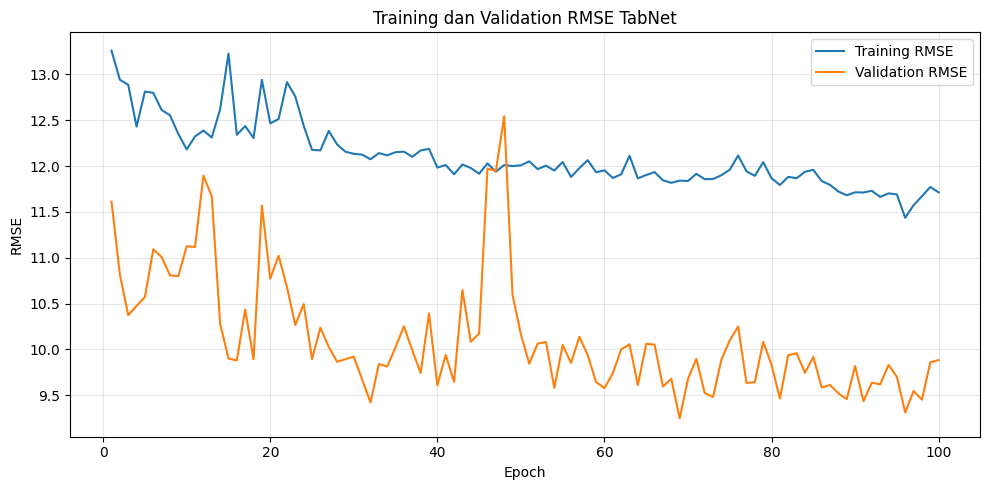

In [78]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(tabnet.history["train_rmse"]) + 1),
    tabnet.history["train_rmse"],
    label="Training RMSE",
    linewidth=1.5
)

plt.plot(
    range(1, len(tabnet.history["valid_rmse"]) + 1),
    tabnet.history["valid_rmse"],
    label="Validation RMSE",
    linewidth=1.5
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training dan Validation RMSE TabNet")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# 5 data yang digunakan
X_manual = X_scaled[:5]
y_manual = y_train_tabnet.iloc[:5].values

# Prediksi TabNet
pred_manual = tabnet.predict(X_manual).flatten()

print("X setelah standardisasi:")
print(X_manual)

print("\nY aktual:")
print(y_manual)

print("\nY prediksi:")
print(pred_manual)

print("\nFeature importance:")
print(tabnet.feature_importances_)

X setelah standardisasi:
[[ 1.255994    0.58505368  0.73491965  0.45850361 -0.29212188 -0.94700118
   0.32916484  0.42461472  0.28518313 -0.46664197 -0.01010651 -0.90213255
   0.35888641  0.33313039 -0.04843449  0.46987271 -0.35041836  0.09110587
   0.14982241  0.24600303]
 [ 1.52035982 -0.58340249  1.14525842  0.76663163  1.31133694  0.78181235
   0.83343585  0.52271805 -0.18632857 -0.46664197 -0.01010651 -0.87276339
   0.4829151   0.2513196  -0.54589179  0.53551733 -0.52627164  0.50498238
   0.04270989  0.04557842]
 [ 1.71622491 -1.18424975  1.3732244   0.84586455  1.64308704 -0.92338351
   0.91748102  0.32651139 -0.37971355 -0.46664197 -0.01010651 -0.37145477
   0.56818483  0.26652337 -0.40556921  0.03020257 -0.99353894 -0.37926486
   0.11411824  0.11572703]
 [ 1.61905202 -0.31238202  0.64373326  0.30884143  1.05330909  0.46533555
   0.41321     0.21614515 -0.28193463 -0.46664197 -0.60315877 -1.10101538
   0.77748324  0.0949379   0.31530364  0.79171597 -0.85976483  0.61755243
  -0.0

In [36]:
masks = tabnet.explain(X_manual)

print("Feature mask:")
print(masks[0])

Feature mask:
[[20.70139885  7.00837517  1.64021778  0.          1.97653449  0.
   2.20675802  0.          2.19294763  0.          0.45066935  0.
   0.          0.24589263  0.14530009  0.          0.          3.42630863
   0.68406576  0.        ]
 [13.71410179 15.29255104  0.          0.          8.79610825  0.
   0.          2.98768544  0.          0.          0.          0.
   0.          2.5289371   0.          2.69624996  0.          2.36759305
   0.          0.        ]
 [13.32429981 28.49345207  7.15169716  0.         11.51699829  0.
   0.          2.7429769   0.          0.          0.          0.
   0.          0.          0.          3.01883578  0.          2.19785571
   0.          0.        ]
 [11.32227421 10.20178604  0.67495131  1.70991421  6.85373878  0.
   0.          0.          0.          0.          0.          0.
   0.          2.26519537  0.          2.54022241  0.          8.0132885
   0.          0.        ]
 [25.5735817   2.51353765  3.1421206   1.40364647  0.  

FEATURE IMPORTANCE TABNET

In [37]:
importance = tabnet.feature_importances_


feature_importance = pd.DataFrame({
    "Feature": features_pearson,
    "Importance": importance
})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


In [38]:
N_FEATURES = 15

selected_features = feature_importance.head(
    N_FEATURES
)["Feature"].tolist()
display(
    feature_importance.head(15)
)

,Feature,Importance
0,Humi0,0.189041
1,LCL,0.185476
2,Temp0,0.089025
3,850,0.071046
4,500,0.067404
5,700,0.053075
6,LFC,0.046147
7,CCL,0.038202
8,CAPE,0.032851
9,TPW,0.030890


PENENTUAN LAG DENGAN CCF
CCF digunakan untuk melihat hubungan antara:
X(t-lag) -> CH(t)
CCF dilakukan hanya pada DATA TRAINING.
MAX_LAG = 7 hari
Lag setiap fitur dapat berbeda.

In [39]:
MAX_LAG = 7

lag_results = []


for feature in selected_features:

    x = df_train[feature].values
    y = df_train[target].values

    # Hilangkan kemungkinan NaN
    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    # CCF
    ccf_values = ccf(
        x,
        y,
        adjusted=False
    )

    # Kandidat lag 1-7
    candidate_ccf = ccf_values[
        1:MAX_LAG + 1
    ]
     # Lag dengan absolut CCF terbesar
    best_idx = np.argmax(
        np.abs(candidate_ccf)
    )

    best_lag = best_idx + 1

    best_ccf = candidate_ccf[
        best_idx
    ]

    lag_results.append({
        "Feature": feature,
        "Lag": best_lag,
        "CCF": best_ccf,
        "Abs_CCF": abs(best_ccf)
    })


lag_df = pd.DataFrame(
    lag_results
)

lag_df = lag_df.sort_values(
    "Abs_CCF",
    ascending=False
).reset_index(drop=True)
display(lag_df)

,Feature,Lag,CCF,Abs_CCF
0,Humi0,1,0.340066,0.340066
1,TPW,1,0.278859,0.278859
2,700,1,0.272521,0.272521
3,LCL,1,-0.271317,0.271317
4,500,1,0.265022,0.265022
5,KI,1,0.235175,0.235175
6,850,1,0.220598,0.220598
7,CCL,1,-0.181829,0.181829
8,CAPE,1,0.143051,0.143051
9,Height,3,-0.131126,0.131126


In [40]:
selected_lags = dict(
    zip(
        lag_df["Feature"],
        lag_df["Lag"]
    )
)

print("\nLag yang digunakan:")

for feature, lag in selected_lags.items():

    print(
        f"{feature} -> lag {lag}"
    )


Lag yang digunakan:
Humi0 -> lag 1
TPW -> lag 1
700 -> lag 1
LCL -> lag 1
500 -> lag 1
KI -> lag 1
850 -> lag 1
CCL -> lag 1
CAPE -> lag 1
Height -> lag 3
LFC -> lag 1
SWEAT -> lag 4
Press0 -> lag 7
MVV -> lag 2
Temp0 -> lag 7


MEMBENTUK DATA LAG
membentuk lag berdasarkan fitur yang sudah dipilih oleh TabNet.
Setiap fitur menggunakan lag hasil CCF masing-masing.

In [41]:
df_model = df1[
    ["Tanggal", target] + selected_features
].copy()

df_model = df_model.sort_values(
    "Tanggal"
).reset_index(drop=True)


for feature, lag in selected_lags.items():

    df_model[
        f"{feature}_lag{lag}"
    ] = df_model[
        feature
    ].shift(lag)



In [42]:
CH_LAG = 1

df_model[
    f"CH_lag{CH_LAG}"
] = df_model[
    "CH"
].shift(CH_LAG)


 FITUR MUSIMAN

In [43]:
df_model["month"] = (
    df_model["Tanggal"].dt.month
)

df_model["month_sin"] = np.sin(
    2 * np.pi *
    df_model["month"] / 12
)

df_model["month_cos"] = np.cos(
    2 * np.pi *
    df_model["month"] / 12
)


MENGHAPUS BARIS AKIBAT LAG

In [44]:
df_model = df_model.dropna(
    subset=[
        f"{feature}_lag{lag}"
        for feature, lag
        in selected_lags.items()
    ]
    +
    [f"CH_lag{CH_LAG}"]
).reset_index(drop=True)


print(df_model.shape)

(2526, 36)


In [45]:
df_model

,Tanggal,CH,Humi0,LCL,Temp0,850,500,700,LFC,CCL,...,Height_lag3,LFC_lag1,SWEAT_lag4,Press0_lag7,MVV_lag2,Temp0_lag7,CH_lag1,month,month_sin,month_cos
0,2019-01-08,6.4,30.210083,545.0,-39.654737,88.5,67.5,65.5,1304.5,1398.0,...,8312.081650,1867.5,210.90,338.183767,57.50,-35.773167,0.0,1,5.000000e-01,0.866025
1,2019-01-09,0.0,32.686168,498.5,-40.225986,72.5,36.5,51.5,1119.0,1459.0,...,14079.259249,1304.5,206.65,342.363058,38.00,-32.865369,6.4,1,5.000000e-01,0.866025
2,2019-01-10,0.0,54.263664,540.0,-34.347223,96.5,56.0,52.0,1087.5,1232.5,...,8715.312832,1119.0,197.10,310.191993,54.50,-39.077880,0.0,1,5.000000e-01,0.866025
3,2019-01-11,0.5,41.852026,362.5,-39.086104,87.5,34.5,70.5,2466.0,1392.5,...,12199.843207,1087.5,235.20,358.674046,68.50,-32.074478,0.0,1,5.000000e-01,0.866025
4,2019-01-12,2.0,42.715199,310.0,-40.033503,78.5,62.0,48.5,1687.5,1593.5,...,13079.497675,2466.0,229.70,478.850790,62.00,-17.090369,0.5,1,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521,2025-12-26,10.0,26.346737,202.0,-40.439256,86.0,85.0,76.0,881.5,840.5,...,14137.291597,1186.0,231.40,267.332154,35.75,-39.322015,35.0,12,-2.449294e-16,1.000000
2522,2025-12-27,10.0,24.766886,486.0,-39.774634,86.0,85.0,76.0,2828.5,1602.0,...,13530.225566,881.5,224.45,288.810663,35.75,-38.897269,10.0,12,-2.449294e-16,1.000000
2523,2025-12-28,0.0,21.007110,660.5,-39.740295,86.0,85.0,76.0,1442.0,1388.0,...,14796.762533,2828.5,224.55,265.720775,35.75,-39.426488,10.0,12,-2.449294e-16,1.000000
2524,2025-12-29,0.0,22.379381,345.0,-39.567432,86.0,85.0,76.0,1574.5,1284.5,...,14481.718041,1442.0,235.75,279.191697,35.75,-38.785340,0.0,12,-2.449294e-16,1.000000


MENENTUKAN FITUR XGBOOST

In [46]:
lag_features = [
    f"{feature}_lag{lag}"
    for feature, lag
    in selected_lags.items()
]


xgb_features = (
    lag_features
    +
    [f"CH_lag{CH_LAG}"]
    +
    [
        "month",
        "month_sin",
        "month_cos"
    ]
)


print("\nJumlah fitur XGBoost:",
      len(xgb_features))

print("\nFitur XGBoost:")
print(xgb_features)


Jumlah fitur XGBoost: 19

Fitur XGBoost:
['Humi0_lag1', 'TPW_lag1', '700_lag1', 'LCL_lag1', '500_lag1', 'KI_lag1', '850_lag1', 'CCL_lag1', 'CAPE_lag1', 'Height_lag3', 'LFC_lag1', 'SWEAT_lag4', 'Press0_lag7', 'MVV_lag2', 'Temp0_lag7', 'CH_lag1', 'month', 'month_sin', 'month_cos']


MEMISAHKAN TRAINING DAN TESTING

In [47]:

train_model = df_model[
    df_model["Tanggal"].dt.year <= 2024
].copy()

test_model = df_model[
    df_model["Tanggal"].dt.year == 2025
].copy()

print(
    "Training :",
    train_model["Tanggal"].min(),
    "sampai",
    train_model["Tanggal"].max(),
    "| n =",
    len(train_model)
)

print(
    "Testing  :",
    test_model["Tanggal"].min(),
    "sampai",
    test_model["Tanggal"].max(),
    "| n =",
    len(test_model)
)

Training : 2019-01-08 00:00:00 sampai 2024-12-31 00:00:00 | n = 2171
Testing  : 2025-01-01 00:00:00 sampai 2025-12-30 00:00:00 | n = 355


TIME-SERIES VALIDATION UNTUK OPTUNA

In [48]:
optuna_train = train_model[
    train_model["Tanggal"].dt.year <= 2023
].copy()

optuna_valid = train_model[
    train_model["Tanggal"].dt.year == 2024
].copy()


X_optuna_train = optuna_train[
    xgb_features
]

y_optuna_train = optuna_train[
    target
]

X_optuna_valid = optuna_valid[
    xgb_features
]

y_optuna_valid = optuna_valid[
    target
]

In [49]:
print(
    "Optuna Training :",
    optuna_train["Tanggal"].min(),
    "sampai",
    optuna_train["Tanggal"].max(),
    "| n =",
    len(optuna_train)
)

print(
    "Validation      :",
    optuna_valid["Tanggal"].min(),
    "sampai",
    optuna_valid["Tanggal"].max(),
    "| n =",
    len(optuna_valid)
)

Optuna Training : 2019-01-08 00:00:00 sampai 2023-12-31 00:00:00 | n = 1806
Validation      : 2024-01-01 00:00:00 sampai 2024-12-31 00:00:00 | n = 365


OPTUNA

In [50]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.005,
            0.1,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            1
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            2
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.1,
            5
        ),

        "objective": "reg:squarederror",

        "random_state": 42,

        "n_jobs": -1
    }


    model = XGBRegressor(
        **params
    )


    model.fit(
        X_optuna_train,
        y_optuna_train
    )


    pred_valid = model.predict(
        X_optuna_valid
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_optuna_valid,
            pred_valid
        )
    )


    return rmse


In [51]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-08-13 15:28:20,122] A new study created in memory with name: no-name-d56af779-19f8-4953-9945-a788ccd6c9f5
[I 2026-08-13 15:28:21,076] Trial 0 finished with value: 12.38544585025661 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.044803926826840625, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.05808361216819946, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 3.0454635575417233}. Best is trial 0 with value: 12.38544585025661.
[I 2026-08-13 15:28:21,198] Trial 1 finished with value: 12.46938089810114 and parameters: {'n_estimators': 383, 'max_depth': 2, 'learning_rate': 0.09138013915892866, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.18340450985343382, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 2.6713065149979656}. Best is trial 0 with value: 12.38544585025661.
[I 2026-08-13 15:28:21,399] Trial 2 finished with value: 12.559389026

In [52]:
print(
    "Best RMSE:",
    study.best_value
)

print("\nBest Parameters:")

for key, value in study.best_params.items():

    print(
        f"{key}: {value}"
    )

Best RMSE: 11.840451898155163

Best Parameters:
n_estimators: 471
max_depth: 2
learning_rate: 0.006240851684979878
subsample: 0.7424863638786444
colsample_bytree: 0.8761475151107455
min_child_weight: 8
gamma: 0.2654530338937755
reg_alpha: 0.3939431450251808
reg_lambda: 2.4263718235006047


TRAINING XGBOOST

In [53]:
X_train_final = train_model[
    xgb_features
]

y_train_final = train_model[
    target
]

X_test_final = test_model[
    xgb_features
]

y_test_final = test_model[
    target
]


best_params = study.best_params.copy()

best_params["objective"] = "reg:squarederror"
best_params["random_state"] = 42
best_params["n_jobs"] = -1


xgb_final = XGBRegressor(
    **best_params
)


xgb_final.fit(
    X_train_final,
    y_train_final
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8761475151107455, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.2654530338937755, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.006240851684979878,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=471, n_jobs=-1,
             num_parallel_tree=None, ...)

In [54]:
pred = xgb_final.predict(
    X_test_final
)

EVALUASI MODEL

In [55]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        pred
    )
)

mae = mean_absolute_error(
    y_test_final,
    pred
)
mask = y_test_final != 0

mape = np.mean(
    np.abs(
        (
            y_test_final[mask]
            -
            pred[mask]
        )
        /
        y_test_final[mask]
    )
) * 10
print(
    "RMSE :",
    round(rmse, 4)
)

print(
    "MAE  :",
    round(mae, 4)
)

print(
    "MAPE :",
    round(mape, 4),
    "%"
)

RMSE : 14.4536
MAE  : 9.5372
MAPE : 16.5054 %


TABEL PREDIKSI

In [56]:
hasil_prediksi = pd.DataFrame({

    "Tanggal":
        test_model["Tanggal"].values,

    "Aktual":
        y_test_final.values,

    "Prediksi":
        pred

})


print("HASIL PREDIKSI 2025")

display(
    hasil_prediksi
)


HASIL PREDIKSI 2025


,Tanggal,Aktual,Prediksi
0,2025-01-01,27.0,16.087088
1,2025-01-02,30.0,9.126855
2,2025-01-03,2.0,10.034621
3,2025-01-04,0.0,11.224256
4,2025-01-05,28.0,16.251741
...,...,...,...
350,2025-12-26,10.0,6.609502
351,2025-12-27,10.0,9.027891
352,2025-12-28,0.0,6.216020
353,2025-12-29,0.0,5.057906


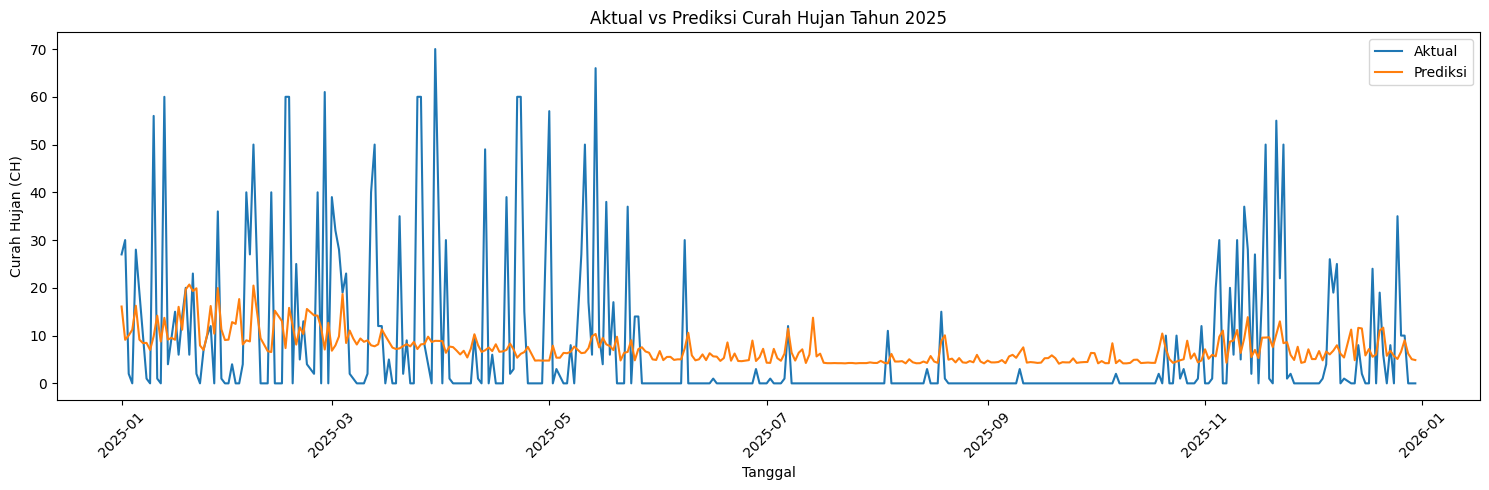

In [57]:
plt.figure(
    figsize=(15, 5)
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Aktual"],
    label="Aktual"
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Prediksi"],
    label="Prediksi"
)

plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (CH)")

plt.title(
    "Aktual vs Prediksi Curah Hujan Tahun 2025"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [58]:
# Cek variabel yang kemungkinan merupakan model
[name for name in globals()
 if "model" in name.lower() or "xgb" in name.lower()]

['XGBRegressor',
 'df_model',
 'xgb_features',
 'train_model',
 'test_model',
 'xgb_final']

In [59]:
# Ambil data tahun 2025
data_2025 = df_model[
    df_model["Tanggal"].dt.year == 2025
].copy()

# Salin data 2025 sebagai simulasi 2026
data_2026 = data_2025.copy()

# Geser tanggal dari 2025 menjadi 2026
data_2026["Tanggal"] = (
    data_2026["Tanggal"] + pd.DateOffset(years=1)
)

# Ambil fitur yang digunakan XGBoost
X_2026 = data_2026[xgb_features].copy()

# Prediksi menggunakan XGBoost final
pred_2026 = xgb_final.predict(X_2026)

# Buat tabel hasil prediksi
hasil_prediksi_2026 = pd.DataFrame({
    "Tanggal": data_2026["Tanggal"].values,
    "Prediksi": pred_2026
})

print("HASIL PREDIKSI 2026")

display(hasil_prediksi_2026)

HASIL PREDIKSI 2026


,Tanggal,Prediksi
0,2026-01-01,16.087088
1,2026-01-02,9.126855
2,2026-01-03,10.034621
3,2026-01-04,11.224256
4,2026-01-05,16.251741
...,...,...
350,2026-12-26,6.609502
351,2026-12-27,9.027891
352,2026-12-28,6.216020
353,2026-12-29,5.057906


In [63]:
# ============================================================
# EXPORT MODEL EXTREME UNTUK STREAMLIT
# ============================================================

import joblib
from google.colab import files

EXPECTED_EXTREME_FEATURES = [
    "Humi0_lag1",
    "TPW_lag1",
    "700_lag1",
    "LCL_lag1",
    "500_lag1",
    "KI_lag1",
    "850_lag1",
    "CCL_lag1",
    "CAPE_lag1",
    "Height_lag3",
    "LFC_lag1",
    "SWEAT_lag4",
    "Press0_lag7",
    "MVV_lag2",
    "Temp0_lag7",
    "CH_lag1",
    "month",
    "month_sin",
    "month_cos",
]

print("xgb_features dari Colab:")
print(xgb_features)

# Cek apakah benar
assert list(xgb_features) == EXPECTED_EXTREME_FEATURES, (
    "xgb_features tidak sesuai dengan pipeline Extreme."
)

print("✓ xgb_features sesuai.")

# Cek jumlah fitur model
print("Jumlah fitur:", len(xgb_features))

# Simpan model
joblib.dump(
    xgb_final,
    "hybrid_extreme.pkl"
)

print("✓ hybrid_extreme.pkl berhasil disimpan.")

# Download
files.download("hybrid_extreme.pkl")

xgb_features dari Colab:
['Humi0_lag1', 'TPW_lag1', '700_lag1', 'LCL_lag1', '500_lag1', 'KI_lag1', '850_lag1', 'CCL_lag1', 'CAPE_lag1', 'Height_lag3', 'LFC_lag1', 'SWEAT_lag4', 'Press0_lag7', 'MVV_lag2', 'Temp0_lag7', 'CH_lag1', 'month', 'month_sin', 'month_cos']
✓ xgb_features sesuai.
Jumlah fitur: 19
✓ hybrid_extreme.pkl berhasil disimpan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>